In [ ]:
import os
import json
import sys
import tempfile
import joblib
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import plot_functions as pf
from scripts.data_preprocessing.process_simulations_for_gnn import *
from scripts.data_preprocessing.help_functions import highway_mapping
from scripts.gnn.models.trans_encoder import TransEncoder
from scripts.training.help_functions import prepare_data_with_graph_features, set_cuda_visible_device
from scripts.gnn.help_functions import select_target_tensor

In [ ]:
is_in_stadt = True
city = "regensburg"
train_count, val_count = 40, 10
seed = 42
test_count = 100
test_set_type = 'random' # or 'distant_iou'

results_dir = '../../data/inductive_gnn_data_results/transductive/Scratch_vs_Finetune/'
plots_dir = '../../plots/'  # Base directory for saving plots (relative to project root)
# Create plots directory structure if it doesn't exist
os.makedirs(os.path.join(plots_dir, 'venn'), exist_ok=True)
os.makedirs(os.path.join(plots_dir, 'errors'), exist_ok=True)
set_cuda_visible_device(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using GPU 0 with CUDA_VISIBLE_DEVICES=0


In [3]:
# Path to basecase files
administrative_boundaries_path = f"../../data/bavaria/inductive_data/links_and_stats/city_boundaries/{city}/{city}.json"
basecase_links_path = f"../../data/bavaria/inductive_data/links_and_stats/basecases_mean/{city}/basecase_average_output_links.geojson"

# Load administrative boundaries
if is_in_stadt:
    gdf_administrative_boundaries = gpd.read_file(administrative_boundaries_path)
    zones_gdf = modify_geodataframe(gdf_administrative_boundaries)

# Load basecase data
gdf_basecase_links = gpd.read_file(basecase_links_path)
gdf_basecase_links = gdf_basecase_links.set_crs("EPSG:25832", allow_override=True)
if is_in_stadt:
    gdf_basecase_links = merge_edges_and_zones(gdf_basecase_links, zones_gdf, is_in_stadt)
    gdf_basecase_links = clean_duplicates_based_on_modes(gdf_basecase_links)

# Explicitly (re)set CRS on final geometry
gdf_basecase_links = gdf_basecase_links.set_crs("EPSG:25832", allow_override=True)

# Convert to WGS84 for plotting, N, E coordinates
gdf_basecase_links = gdf_basecase_links.to_crs("EPSG:4326")

Total edges in original file: 13107

Full duplicates (same from_node, to_node, geometry, modes): 80

=== EXAMPLES OF FULL DUPLICATES ===

Full Duplicate Group 1:
          link    from_node    to_node              modes   vol_car
26470  1955242  10960543384  479529118  car,car_passenger  0.979167
39772   417087  10960543384  479529118  car,car_passenger  1.812500

Full Duplicate Group 2:
          link  from_node     to_node              modes  vol_car
28802  2046093  120015340  9897801757  car,car_passenger     0.00
43320   552339  120015340  9897801757  car,car_passenger     1.75

Full Duplicate Group 3:
          link  from_node    to_node              modes   vol_car
28630  2039613  120016090  120016090  car,car_passenger  1.979167
28631  2039614  120016090  120016090  car,car_passenger  0.000000

... and 37 more full duplicate groups (not shown) ...
Edges after removing full duplicates (based on higher car volume): 13067
Number of full duplicates removed: 40

Leftover duplicates (

In [4]:
# Debug anamolies for plotting (longest links)
print(gdf_basecase_links['length'].nlargest(10))

# Regensburg: 4
# Schweinfurt: 6
# Wuerzburg: 0
# Bamberg: 0
# Landshut: 0
# Bayreuth: 0
top_z_links = 4

55760    3950.593411
55759    3630.969446
55763    3507.422615
55758    3441.890772
55761    3436.730495
55762    3390.279970
41988    1348.541018
41989    1348.541018
41986    1051.270605
41987    1051.270605
Name: length, dtype: float64


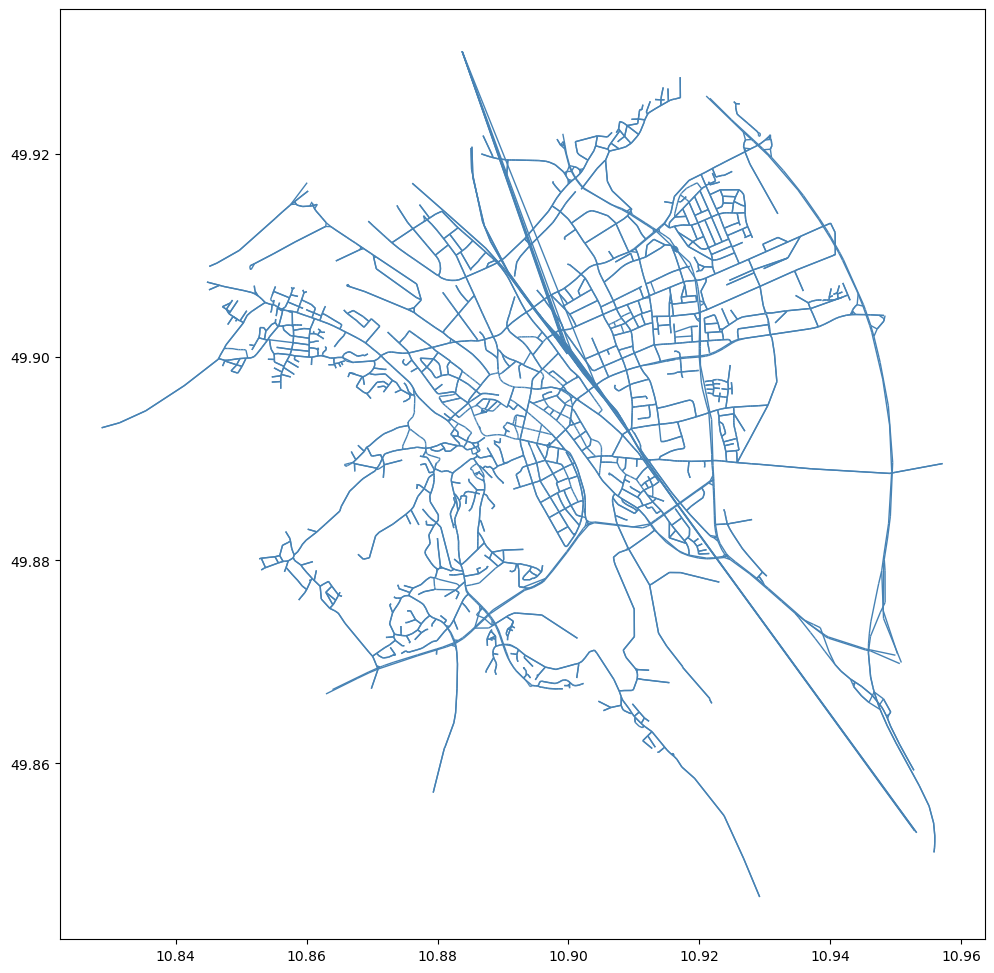

In [5]:
# rows_to_drop = gdf_basecase_links['length'].nlargest(top_z_links).index
# gdf_basecase_links = gdf_basecase_links.drop(rows_to_drop)

# Test Plotting
ax = gdf_basecase_links.plot(figsize=(10, 10), linewidth=1, edgecolor="steelblue")
plt.tight_layout()
plt.show()

### Get Test Results

In [ ]:
def replace_path_for_retina(data_split):
    """Replace various absolute paths with relative paths to make the notebook portable."""
    new_paths = []
    for path in data_split['path']:
        # Replace /mnt/repo/ with relative path
        if path.startswith('/mnt/repo/'):
            path = path.replace('/mnt/repo/', '../../')
        # Replace /home/rrao/development/gnn_predicting_effects_of_traffic_policies/ with relative path
        elif path.startswith('/home/rrao/development/gnn_predicting_effects_of_traffic_policies/'):
            path = path.replace('/home/rrao/development/gnn_predicting_effects_of_traffic_policies/', '../../')
        # Replace any other /home/rrao/... paths that contain the project name
        elif path.startswith('/home/rrao/') and 'gnn_predicting_effects_of_traffic_policies/' in path:
            # Extract the part after the project root
            rel_part = path.split('gnn_predicting_effects_of_traffic_policies/')[1]
            path = '../../' + rel_part
        
        new_paths.append(path)
    data_split['path'] = new_paths
    return data_split

def get_predictions(seed_idx):

    split_file_path = f"../../data/splits/{city}/rs_{seed_idx}/t{train_count}_v{val_count}/{city}_rs{seed_idx}_t{train_count}_v{val_count}_seed{seed+seed_idx-1}_train{train_count}_val{val_count}_test{test_count}_{test_set_type}.json"
    scratch_run_name = f"{city}_scratch_rs_{seed_idx}_t{train_count}_v{val_count}"
    finetune_run_name = f"{city}_finetune_rs_{seed_idx}_t{train_count}_v{val_count}"
    x_scaler_path = results_dir + finetune_run_name + "/data_created_during_finetuning/train_x_scaler.pkl"

    scratch_gnn = TransEncoder()
    finetune_gnn = TransEncoder()

    # Load the model state dictionary
    scratch_gnn.load_state_dict(torch.load(results_dir + scratch_run_name + '/finetuned_model/model.pth'))
    finetune_gnn.load_state_dict(torch.load(results_dir + finetune_run_name + '/finetuned_model/model.pth'))

    scratch_gnn.to(device)
    finetune_gnn.to(device)

    with open(split_file_path, "r") as f:
        split_data = json.load(f)

    test_data = replace_path_for_retina(split_data.get("test_data"))
    train_data = replace_path_for_retina(split_data.get("train_data"))
    val_data = replace_path_for_retina(split_data.get("val_data"))

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)
        # Ensure the directory exists and use proper path joining with trailing slash
        # (required because prepare_data_with_graph_features uses string concatenation)
        path_to_save_dataloader = str(tmp_dir) + os.sep
        os.makedirs(path_to_save_dataloader, exist_ok=True)
        _, _, test_loader = prepare_data_with_graph_features(
            train_data=train_data,
            val_data=val_data,
            test_data=test_data,
            use_inductive_variant=False,
            batch_size=1,
            path_to_save_dataloader=path_to_save_dataloader,
            use_all_features=False,
            use_weighted_batches=False,
            use_nested_neighbor_loader=False,
            neighbor_sizes="7,7,7",
            subgraphs_per_graph=1,
            seed_size=1000,
            sampling_strategy="neighbor_sampling",
            min_subgraph_nodes=5000,
            max_subgraph_nodes=50000,
            aug_pos_rotation=False,
            aug_feature_noise=False,
            aug_node_masking_probability=0.0,
            use_destination_activity_param=False,
            return_test_loader=True,
            x_scaler_path=x_scaler_path
        )

        scratch_gnn.eval()
        finetune_gnn.eval()
        
        scratch_predictions = []
        finetune_predictions = []
        targets = []
        redux = []
        vol_base_case = []

        x_scaler = joblib.load(x_scaler_path)

        with torch.inference_mode():    
            for batch in test_loader:
                batch = batch.to(device)

                conti_feat = batch.x[:,[0,1,3,4]].cpu()
                reat_feat = x_scaler.inverse_transform(conti_feat)
                vol_base_case.append(reat_feat[:,0])

                redux.append(batch.x[:,2].cpu())
                
                out = scratch_gnn(batch.clone())
                scratch_predictions.append(out.cpu())

                out = finetune_gnn(batch)
                finetune_predictions.append(out.cpu())
                
                targets_node_predictions = select_target_tensor(batch, "abs_vol_car")
                targets.append(targets_node_predictions.cpu())

    return torch.stack(scratch_predictions).squeeze().numpy(), torch.stack(finetune_predictions).squeeze().numpy(), torch.stack(targets).squeeze().numpy(), torch.stack(redux).squeeze().numpy(), np.stack(vol_base_case).squeeze()

In [7]:
scratch_predictions, finetune_predictions, targets, reduxs, vol_base_casex = dict(), dict(), dict(), dict(), dict()
for seed_idx in tqdm(range(1,6)):
    sp, fp, t, r, vbc = get_predictions(seed_idx)
    scratch_predictions[seed_idx] = sp
    finetune_predictions[seed_idx] = fp
    targets[seed_idx] = t
    reduxs[seed_idx] = r
    vol_base_casex[seed_idx] = vbc

  0%|          | 0/5 [00:00<?, ?it/s]/opt/anaconda3/envs/chenhao-gnn/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Preparing data with 150 items
Splitting into subsets...
Total dataset length: 150
Training subset length: 40
Validation subset length: 10
Test subset length: 100
[DEBUG] Train subset label counts (total 40):
  bamberg: 40
[DEBUG] Validation subset label counts (total 10):
  bamberg: 10
[DEBUG] Test subset label counts (total 100):
  bamberg: 100
[VERIFICATION] ✓ No data leakage (TRANSDUCTIVE): Same cities allowed, but 40 training, 10 validation, and 100 test graphs are non-overlapping
Split complete. Train: 40, Valid: 10, Test: 100
['VOL_BASE_CASE', 'CAPACITY_BASE_CASE', 'CAPACITY_REDUCTION', 'FREESPEED', 'LENGTH']
Global feature mapping: {0: 0, 1: 1, 2: 2, 3: 3, 10: 4}
Data Augmentation Settings:
Pos Rotation Augmentation: False Feature Noise Augmentation: False Node Masking Probability: 0.0
Use Nested Neighbor Loader: False
Normalizing train set...
Loading pre-fitted x_scaler from ../../data/inductive_gnn_data_results/transductive/Scratch_vs_Finetune/bamberg_finetune_rs_1_t40_v10/dat

/opt/anaconda3/envs/chenhao-gnn/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Normalizing x features with existing scaler...


Normalizing x features: 100%|██████████| 1/1 [00:00<00:00, 41.50it/s]


...

Normalizing x features with existing scaler...


Normalizing x features: 100%|██████████| 1/1 [00:00<00:00, 13.04it/s]

x features normalized
Test set normalized
Creating train loader...
Train loader created
Creating validation loader...
Validation loader created
Creating test loader...


Test Dataloader saved since Transductive Variant.
Test loader created
Scaler saved!


/opt/anaconda3/envs/chenhao-gnn/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.0 when using version 1.4.1.post1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
100%|██████████| 5/5 [01:22<00:00, 16.59s/it]


### Predictive Analysis (Overlaps)

In [8]:
def get_overlaps(s_preds, f_preds, targs, rdx,
                 k=10, direction='bottom', verbose=False):
    """
    Calculate overlap between model predictions and targets for top/bottom k scenarios.
    
    Args:
        s_preds: Scratch model predictions (num_scenarios, num_links)
        f_preds: Finetune model predictions (num_scenarios, num_links)
        targs: Target values (num_scenarios, num_links)
        rdx: Capacity reduction mask (num_scenarios, num_links)
        k: Number of top/bottom scenarios to consider
        direction: 'top' for highest values, 'bottom' for lowest values
        verbose: Whether to print selected scenarios
    
    Returns:
        Tuple of (scratch_overlap, finetune_overlap) as proportions
    """
    # Filter scenarios with minimal capacity reduction (< 5% of links)
    redux_filter = rdx.sum(axis=1) < rdx.shape[1] * 0.005
    
    # Check if we have enough filtered scenarios
    num_filtered = redux_filter.sum()
    if num_filtered == 0:
        raise ValueError("No scenarios pass the capacity reduction filter")
    if k > num_filtered:
        k = num_filtered
        if verbose:
            print(f"Warning: k reduced to {k} (number of filtered scenarios)")
    
    # Sum predictions/targets across all links for each scenario
    scratch_preds_total = s_preds[redux_filter].sum(axis=1)
    finetune_preds_total = f_preds[redux_filter].sum(axis=1)
    targets_total = targs[redux_filter].sum(axis=1)
    
    # Get top/bottom k scenario indices
    if direction == 'top':
        # Get k scenarios with highest total change (most impact)
        scratch_top_scenarios = set(scratch_preds_total.argsort()[-k:])
        finetune_top_scenarios = set(finetune_preds_total.argsort()[-k:])
        targets_top_scenarios = set(targets_total.argsort()[-k:])
    elif direction == 'bottom':
        # Get k scenarios with lowest total change (least impact)
        scratch_top_scenarios = set(scratch_preds_total.argsort()[:k])
        finetune_top_scenarios = set(finetune_preds_total.argsort()[:k])
        targets_top_scenarios = set(targets_total.argsort()[:k])
    else:
        raise ValueError("direction must be 'top' or 'bottom'")
    
    if verbose:
        print(f"Scratch {direction.capitalize()} {k} Scenarios:")
        print(scratch_top_scenarios)
        print(f"Finetune {direction.capitalize()} {k} Scenarios:")
        print(finetune_top_scenarios)
        print(f"Target {direction.capitalize()} {k} Scenarios:")
        print(targets_top_scenarios)
    
    # Calculate overlap proportions
    scratch_overlap = len(scratch_top_scenarios.intersection(targets_top_scenarios)) / k
    finetune_overlap = len(finetune_top_scenarios.intersection(targets_top_scenarios)) / k
    
    return round(scratch_overlap, 2), round(finetune_overlap, 2)
    

In [9]:
k_values = [1, 5, 10, 20]
overlap_results = dict()

for k in tqdm(k_values):
    scratch_overlaps, finetune_overlaps = [], []
    for seed_idx in range(1,6):
        s_preds = scratch_predictions[seed_idx]
        f_preds = finetune_predictions[seed_idx]
        targs = targets[seed_idx]
        rdx = reduxs[seed_idx]

        s_overlap, f_overlap = get_overlaps(s_preds, f_preds, targs, rdx, k=k)
        scratch_overlaps.append(s_overlap)
        finetune_overlaps.append(f_overlap)
    
    overlap_results[k] = [scratch_overlaps, finetune_overlaps]

100%|██████████| 4/4 [00:00<00:00, 64.91it/s]


In [10]:
for k, (s_overlaps, f_overlaps) in overlap_results.items():
    print(f"Top {k} Overlaps:")
    print(f"Scratch: {s_overlaps}")
    print(f"Finetune: {f_overlaps}")
    print()

Top 1 Overlaps:
Scratch: [0.0, 0.0, 0.0, 0.0, 0.0]
Finetune: [0.0, 0.0, 0.0, 0.0, 0.0]

Top 5 Overlaps:
Scratch: [0.2, 0.6, 0.2, 0.4, 0.4]
Finetune: [0.4, 0.4, 0.0, 0.6, 0.4]

Top 10 Overlaps:
Scratch: [0.5, 0.5, 0.4, 0.5, 0.3]
Finetune: [0.4, 0.4, 0.4, 0.5, 0.4]

Top 20 Overlaps:
Scratch: [0.7, 0.7, 0.75, 0.65, 0.45]
Finetune: [0.7, 0.7, 0.6, 0.75, 0.6]



In [11]:
for k, (s_overlaps, f_overlaps) in overlap_results.items():
    s_mean = round(np.mean(s_overlaps),2)
    s_std = round(np.std(s_overlaps),2)
    f_mean = round(np.mean(f_overlaps),2)
    f_std = round(np.std(f_overlaps),2)
    print(f"Top-{k} & ${s_mean} \\pm {s_std}$ & ${f_mean} \\pm {f_std}$ & $+{round(f_mean - s_mean,2)}$ \\\\")

Top-1 & $0.0 \pm 0.0$ & $0.0 \pm 0.0$ & $+0.0$ \\
Top-5 & $0.36 \pm 0.15$ & $0.36 \pm 0.2$ & $+0.0$ \\
Top-10 & $0.44 \pm 0.08$ & $0.42 \pm 0.04$ & $+-0.02$ \\
Top-20 & $0.65 \pm 0.1$ & $0.67 \pm 0.06$ & $+0.02$ \\


In [12]:
l;lkjf

NameError: name 'l' is not defined

### Plots by Hit Type (Venn Like)

In [ ]:
color_mapping = {
    0: 'lightgrey',  # Not relevant
    1: 'red',    # Missed by both
    2: 'blue',          # Scratch only
    3: 'green',         # Finetune only
    4: 'black',        # Hit by both
    5: 'orange'        # False Positives
}

In [ ]:
def get_top_k_map(arr, k=5, direction='bottom'):

    top_bool = np.zeros_like(arr, dtype=bool)
    
    if direction == 'top':
        threshold = np.percentile(arr, 100 - k)
        top_bool[arr >= threshold] = True
    elif direction == 'bottom':
        threshold = np.percentile(arr, k)
        top_bool[arr < threshold] = True
    else:
        raise ValueError("direction must be 'top' or 'bottom'")
    return top_bool

def get_venn_map(k=5, direction='bottom',
                 idx = 32, seed_idx=1):

    scratch_topk = get_top_k_map(scratch_predictions[seed_idx][idx], k=k, direction=direction)
    finetune_topk = get_top_k_map(finetune_predictions[seed_idx][idx], k=k, direction=direction)
    target_topk = get_top_k_map(targets[seed_idx][idx], k=k, direction=direction)

    venn_map = np.zeros_like(scratch_predictions[seed_idx][idx], dtype=int)
    venn_map[(~scratch_topk) & (~finetune_topk) & (target_topk)] = 1 # Missed by both 
    venn_map[(scratch_topk) & (~finetune_topk) & (target_topk)] = 2 # Scratch only
    venn_map[(~scratch_topk) & (finetune_topk) & (target_topk)] = 3 # Finetune only
    venn_map[(scratch_topk) & (finetune_topk) & (target_topk)] = 4 # Hit by both
    venn_map[((scratch_topk) | (finetune_topk)) & (~target_topk)] = 5 # False Positives

    return venn_map

def plot_venn_map(venn_map, color_mapping,
                  k=5, direction='bottom',
                  seed_idx=1, idx=32, save=False):

    gdf_basecase_with_venn = gdf_basecase_links.copy()
    gdf_basecase_with_venn['venn_map'] = venn_map
    gdf_basecase_with_venn['redux'] = reduxs[seed_idx][idx].astype(int)

    # To remove outliers
    rows_to_drop = gdf_basecase_with_venn['length'].nlargest(top_z_links).index
    gdf_basecase_with_venn = gdf_basecase_with_venn.drop(rows_to_drop)

    fig, ax = plt.subplots(figsize=(10, 10))
    for venn_value, color in color_mapping.items():

        # No capacity reduction
        subset = gdf_basecase_with_venn[(gdf_basecase_with_venn['venn_map'] == venn_value) & (gdf_basecase_with_venn['redux'] == 0)]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=f'Venn Value {venn_value}', linewidth=1)

        # With capacity reduction
        subset = gdf_basecase_with_venn[(gdf_basecase_with_venn['venn_map'] == venn_value) & (gdf_basecase_with_venn['redux'] == 1)]
        if not subset.empty:
            subset.plot(ax=ax, color=color, label=f'Venn Value {venn_value} - Reduced', linewidth=3.2)
    
    if save:
        # Create directory if it doesn't exist
        save_path = os.path.join(plots_dir, 'venn', city, f'{direction}_{k}', f'seed_{seed_idx}_idx_{idx}.png')
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

Venn Map Value Counts:
Missed by both: 223
Scratch only: 63
Finetune only: 189
Hit by both: 618
False Positives: 522


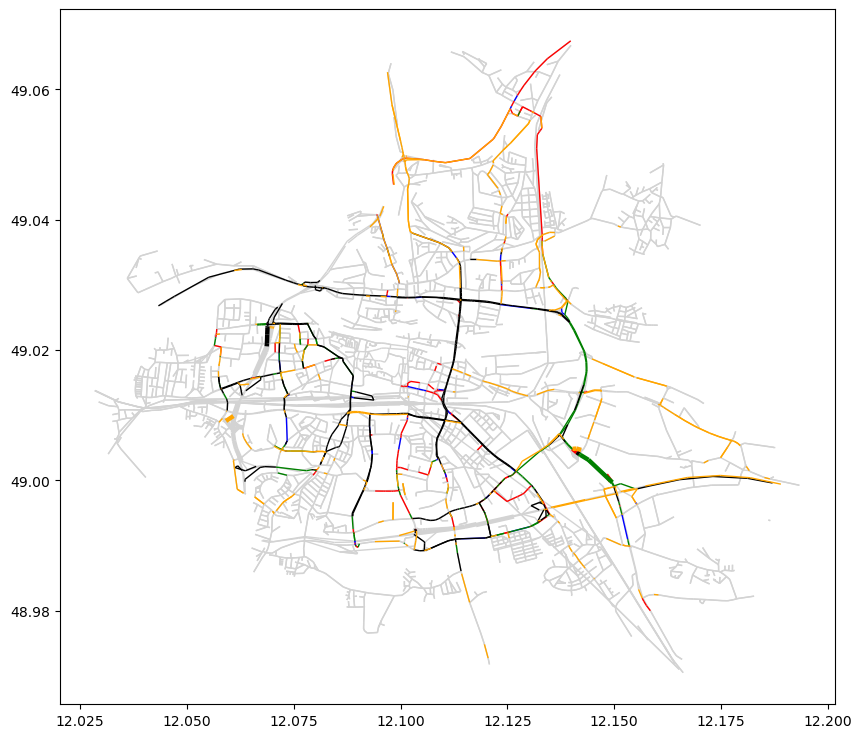

In [ ]:
# Change to desired values
idx = 26 # test sample
seed_idx = 1 # seed index
k = 10 # percentile
direction = 'top' # 'top' or 'bottom'

venn_map = get_venn_map(k=k, direction=direction,
                        idx = idx, seed_idx=seed_idx)

plot_venn_map(venn_map, color_mapping=color_mapping,
              k=k, direction=direction,
              seed_idx=seed_idx, idx=idx)

vals, counts = np.unique(venn_map, return_counts=True)

print("Venn Map Value Counts:")
for v, c in zip(vals, counts):
    if v == 1:
        print(f"Missed by both: {c}")
    elif v == 2:
        print(f"Scratch only: {c}")
    elif v == 3:
        print(f"Finetune only: {c}")
    elif v == 4:
        print(f"Hit by both: {c}")
    elif v == 5:
        print(f"False Positives: {c}")

  0%|          | 0/5 [01:35<?, ?it/s]


KeyboardInterrupt: 

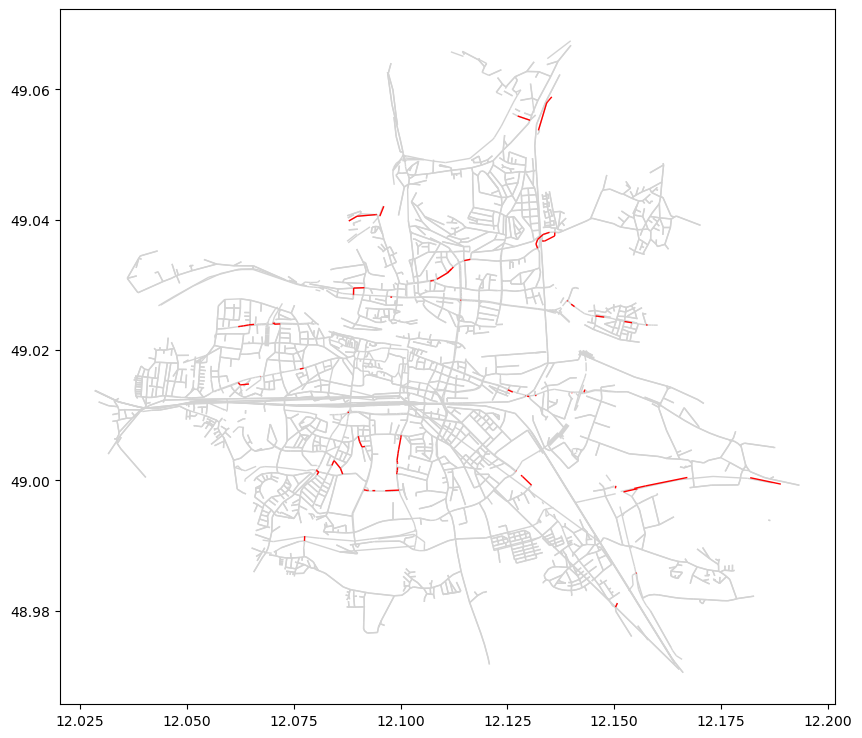

In [ ]:
# PLOT and SAVE ALL
for seed_idx in tqdm(range(1,6)):
    for idx in range(100):
        for dirc in ['top', 'bottom']:
            for k in [5]:
                venn_map = get_venn_map(k=k, direction=dirc,
                                        idx = idx, seed_idx=seed_idx)
                
                plot_venn_map(venn_map, color_mapping=color_mapping,
                              k=k, direction=dirc,
                              seed_idx=seed_idx, idx=idx, save=True)

### Paris like Plots (Errors)

In [ ]:
def data_to_geodataframe_with_og_values(original_gdf, predicted_values, target_values, vol_base_case):
    
    target_values = target_values.cpu().numpy() if isinstance(target_values, torch.Tensor) else target_values
    predicted_values = predicted_values.cpu().numpy() if isinstance(predicted_values, torch.Tensor) else predicted_values
    
    edge_data = {
        'from_node': original_gdf["from_node"].values,
        'to_node': original_gdf["to_node"].values,
        'vol_car_change_actual': target_values,
        'vol_car_change_predicted': predicted_values,
        'vol_base_case': vol_base_case,
        'highway': original_gdf['highway'].values,
        'length': original_gdf['length'].values
    }
    
    edge_df = pd.DataFrame(edge_data)
    edge_df['geometry'] = original_gdf["geometry"].values
    gdf = gpd.GeoDataFrame(edge_df, geometry='geometry')
    gdf['highway'] = gdf['highway'].map(highway_mapping)
    
    return gdf

In [ ]:
plot_scratch = False

# Create gdfs for the entire test set
# Separate for scratch and finetune
gdfs = []

for seed_idx in tqdm(range(1,6)):
    for i in range(100):
        
        gdf = data_to_geodataframe_with_og_values(original_gdf=gdf_basecase_links,
                                                  predicted_values=scratch_predictions[seed_idx][i] if plot_scratch else finetune_predictions[seed_idx][i],
                                                  target_values=targets[seed_idx][i],
                                                  vol_base_case=vol_base_casex[seed_idx][i])

        rows_to_drop = gdf['length'].nlargest(top_z_links).index
        gdf = gdf.drop(rows_to_drop)
        
        gdfs.append(gdf)

In [ ]:
# Discrete plot for prediction error
# Absolute differences in number of vehicles
discrete_thresholds=(5,10,15)

result_gdf = pf.plot_average_prediction_differences(
    gdf_inputs=gdfs,
    scale_type="discrete",
    discrete_thresholds=discrete_thresholds,
    save_it=True,
    use_fixed_norm=True,
    fixed_norm_max=100,
    use_absolute_value_of_difference=True,
    use_percentage=False,
    disagreement_threshold=None,
    result_path=os.path.join(plots_dir, 'errors', f'{city}_{train_count}_{val_count}_{"scratch" if plot_scratch else "finetune"}_absolute.png'),
    loss_fct="l1",
    cmap = 'Spectral_r'
)

In [ ]:
# Continuous plot for prediction error, relative difference.
discrete_thresholds = (10, 25, 50)

result_gdf = pf.plot_average_prediction_differences(
    gdf_inputs=gdfs,
    scale_type="discrete",
    discrete_thresholds=discrete_thresholds,
    save_it=True,
    use_fixed_norm=True,
    fixed_norm_max=100,
    use_absolute_value_of_difference=True,
    use_percentage=True,
    disagreement_threshold=None,
    result_path=os.path.join(plots_dir, 'errors', f'{city}_{train_count}_{val_count}_{"scratch" if plot_scratch else "finetune"}_relative.png'),
    loss_fct="l1",
    cmap = 'Spectral_r'
)

#### Hack: Compare Scratch vs Finetune

In [ ]:
# Create gdfs for the entire test set
gdfs = []

for seed_idx in tqdm(range(1,6)):
    for i in range(100):
        
        gdf = data_to_geodataframe_with_og_values(original_gdf=gdf_basecase_links,
                                                  predicted_values=np.abs(finetune_predictions[seed_idx][i] - targets[seed_idx][i]),
                                                  target_values=np.abs(scratch_predictions[seed_idx][i] - targets[seed_idx][i]),
                                                  vol_base_case=vol_base_casex[seed_idx][i])

        rows_to_drop = gdf['length'].nlargest(top_z_links).index
        gdf = gdf.drop(rows_to_drop)
        
        gdfs.append(gdf)

In [ ]:
# Discrete plot for prediction error
# Absolute differences in number of vehicles
discrete_thresholds=(2,5,10)

result_gdf = pf.plot_average_prediction_differences(
    gdf_inputs=gdfs,
    scale_type="discrete",
    discrete_thresholds=discrete_thresholds,
    save_it=True,
    use_fixed_norm=True,
    fixed_norm_max=100,
    use_absolute_value_of_difference=False,
    use_percentage=False,
    disagreement_threshold=None,
    result_path=os.path.join(plots_dir, 'errors', f'{city}_{train_count}_{val_count}_diff_absolute.png'),
    loss_fct="l1",
    cmap = 'Spectral_r'
)

In [ ]:
# Continuous plot for prediction error, relative difference.
discrete_thresholds = (10, 25, 50)

result_gdf = pf.plot_average_prediction_differences(
    gdf_inputs=gdfs,
    scale_type="discrete",
    discrete_thresholds=discrete_thresholds,
    save_it=True,
    use_fixed_norm=True,
    fixed_norm_max=100,
    use_absolute_value_of_difference=False,
    use_percentage=True,
    disagreement_threshold=None,
    result_path=os.path.join(plots_dir, 'errors', f'{city}_{train_count}_{val_count}_diff_relative.png'),
    loss_fct="l1",
    cmap = 'Spectral_r'
)